In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 맥 기본 한글 폰트 설정
mpl.rc('font', family='AppleGothic')

# 음수 기호 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

print("한글 폰트 AppleGothic 설정 완료!")

한글 폰트 AppleGothic 설정 완료!


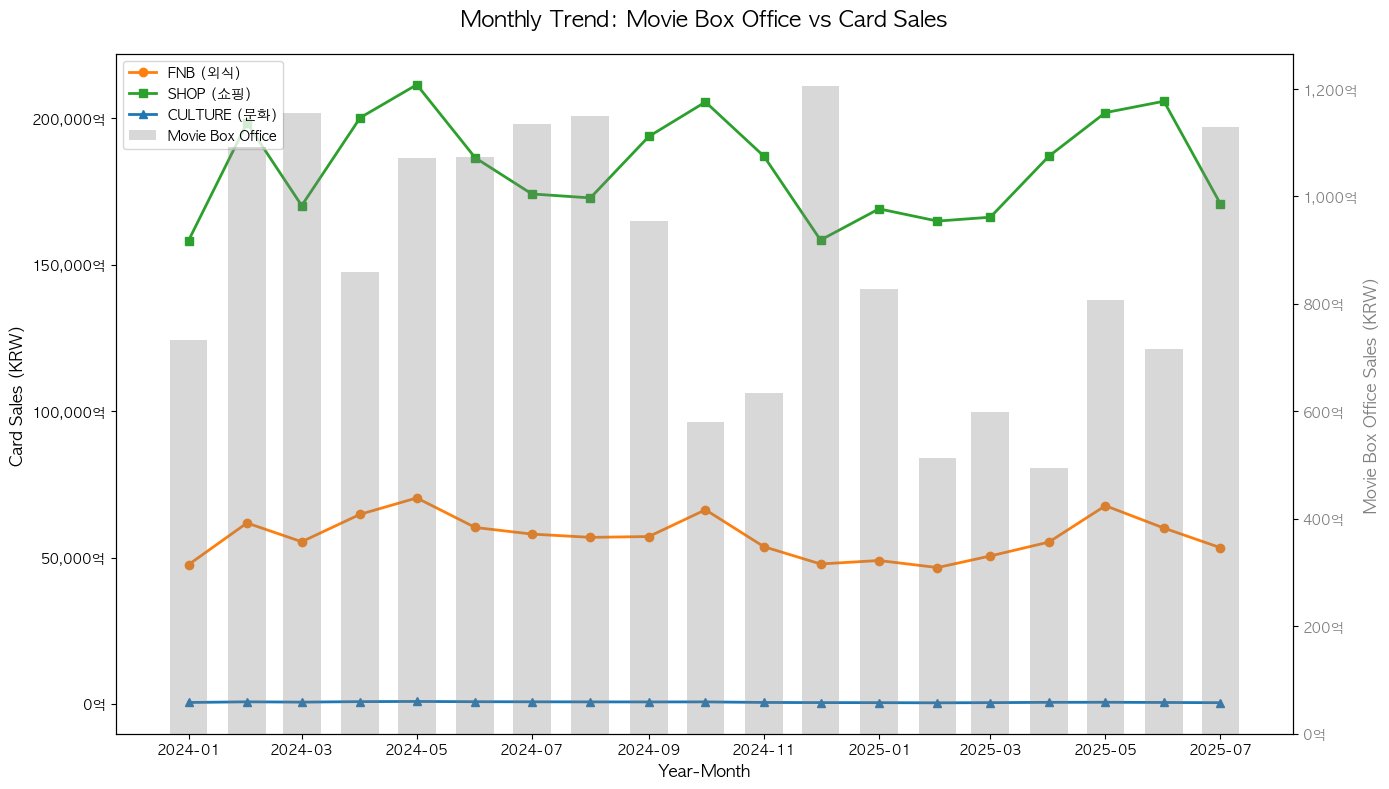

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# --------------------------------------------------------------------------
# 1. 데이터 로드 및 설정
# --------------------------------------------------------------------------
# 사용자 지정 경로
base_path = "/Users/limtae-kyu/culture-policy-card-movie/data"

# 파일 읽기
movie_df = pd.read_csv(f"{base_path}/movie_monthly_cumulative.csv")
card_df = pd.read_csv(f"{base_path}/panel_sido_month.csv")

# 한글 폰트 설정 (Mac OS의 경우 'AppleGothic', 윈도우는 'Malgun Gothic' 등 사용)
# plt.rcParams['font.family'] = 'AppleGothic'
# plt.rcParams['axes.unicode_minus'] = False

# --------------------------------------------------------------------------
# 2. 데이터 전처리
# --------------------------------------------------------------------------

# (1) 영화 데이터: 월별 총 매출액 집계
# YM 컬럼을 기준으로 그룹화하여 매출액(SALES_PRICE) 합계 계산
movie_monthly = movie_df.groupby('YM')['SALES_PRICE'].sum().reset_index()
movie_monthly['YM'] = pd.to_datetime(movie_monthly['YM'].astype(str), format='%Y%m')
movie_monthly.rename(columns={'SALES_PRICE': 'Movie_Sales'}, inplace=True)

# (2) 카드 데이터: 월별 업종별 총 매출액 집계
# TA_YM 컬럼을 기준으로 그룹화하여 각 업종(FNB, SHOP, CULTURE) 합계 계산
card_monthly = card_df.groupby('TA_YM')[['FNB', 'SHOP', 'CULTURE']].sum().reset_index()
card_monthly['TA_YM'] = pd.to_datetime(card_monthly['TA_YM'].astype(str), format='%Y%m')

# (3) 데이터 병합
merged_df = pd.merge(card_monthly, movie_monthly, left_on='TA_YM', right_on='YM', how='inner')

# --------------------------------------------------------------------------
# 3. 시각화 (이중 축 그래프)
# --------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 8))

# X축 설정
x = merged_df['TA_YM']

# [왼쪽 Y축] 카드 매출 (선 그래프)
# 선 두께와 마커를 통해 가독성을 높임
line1 = ax1.plot(x, merged_df['FNB'], label='FNB (외식)', color='#FF7F0E', linewidth=2, marker='o')
line2 = ax1.plot(x, merged_df['SHOP'], label='SHOP (쇼핑)', color='#2CA02C', linewidth=2, marker='s')
line3 = ax1.plot(x, merged_df['CULTURE'], label='CULTURE (문화)', color='#1F77B4', linewidth=2, marker='^')

ax1.set_xlabel('Year-Month', fontsize=12)
ax1.set_ylabel('Card Sales (KRW)', fontsize=12, fontweight='bold')
# Y축 단위를 '억' 단위 등으로 보기 좋게 포맷팅
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/100000000:,.0f}억'))

# [오른쪽 Y축] 영화 매출 (막대 그래프)
# 투명도(alpha)를 주어 선 그래프를 가리지 않도록 설정
ax2 = ax1.twinx()
bar = ax2.bar(x, merged_df['Movie_Sales'], label='Movie Box Office', color='gray', alpha=0.3, width=20)

ax2.set_ylabel('Movie Box Office Sales (KRW)', fontsize=12, fontweight='bold', color='gray')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/100000000:,.0f}억'))
ax2.tick_params(axis='y', labelcolor='gray')

# [범례 및 타이틀 설정]
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
# 막대 그래프 범례 추가
lines += [bar]
labels += [bar.get_label()]

ax1.legend(lines, labels, loc='upper left', fontsize=10, frameon=True)
plt.title('Monthly Trend: Movie Box Office vs Card Sales', fontsize=16, pad=20)
plt.grid(True, axis='x', linestyle='--')

# 그래프 출력
plt.tight_layout()
plt.show()

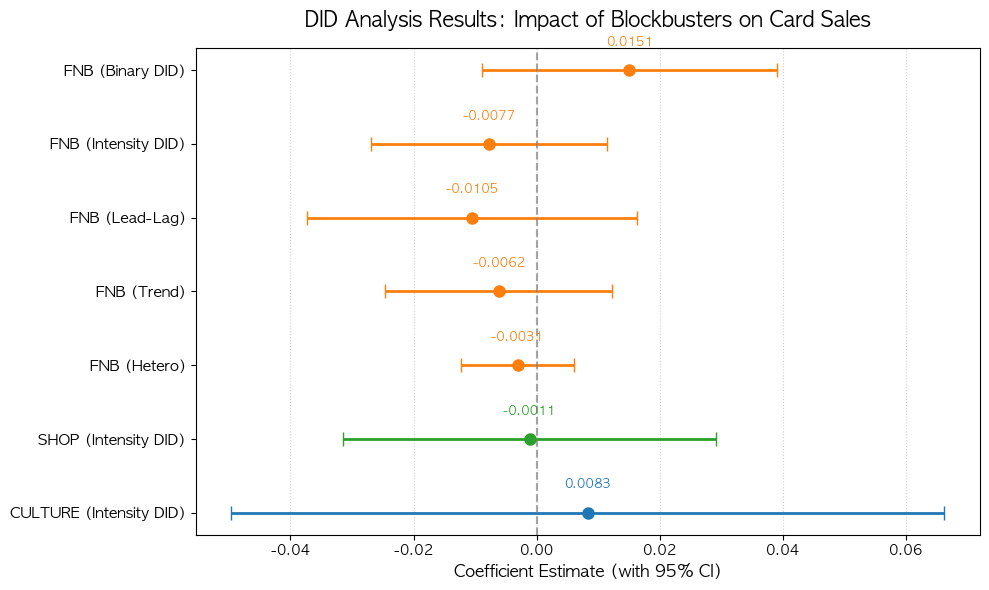

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# 1. 데이터 로드
# --------------------------------------------------------------------------
# 사용자 지정 경로
base_path = "/Users/limtae-kyu/culture-policy-card-movie/data"
df_v1 = pd.read_csv(f"{base_path}/did_results_summary.csv")

# --------------------------------------------------------------------------
# 2. 데이터 전처리
# --------------------------------------------------------------------------
# 분석 결과 중 'DID'(이진 변수)와 'DID_INT'(강도 변수) 항만 추출
target_terms = ['DID', 'DID_INT']
plot_df = df_v1[df_v1['term'].isin(target_terms)].copy()

# 모델명 매핑 (보고서 용어에 맞춰 정리) 및 색상 지정
# FNB=주황, SHOP=초록, CULTURE=파랑 (시계열 그래프와 깔끔하게 통일)
model_mapping = {
    'A_binary_FNB_content': ('FNB (Binary DID)', '#FF7F0E'),
    'B_intensity_FNB_content': ('FNB (Intensity DID)', '#FF7F0E'),
    'C_intensity_leadlag_FNB': ('FNB (Lead-Lag)', '#FF7F0E'),
    'D_intensity_trend_FNB': ('FNB (Trend)', '#FF7F0E'),
    'E_intensity_hetero_FNB': ('FNB (Hetero)', '#FF7F0E'),
    'intensity_logVLM_SHOP': ('SHOP (Intensity DID)', '#2CA02C'),
    'intensity_logVLM_CULTURE': ('CULTURE (Intensity DID)', '#1F77B4')
}

# 매핑 적용
plot_df['label'] = plot_df['model'].map(lambda x: model_mapping.get(x, (x, 'black'))[0])
plot_df['color'] = plot_df['model'].map(lambda x: model_mapping.get(x, (x, 'black'))[1])

# 그래프 순서 정렬 (CULTURE -> SHOP -> FNB 순으로 쌓이도록 역순 정렬)
plot_df = plot_df.iloc[::-1].reset_index(drop=True)

# --------------------------------------------------------------------------
# 3. 시각화 (Forest Plot)
# --------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# 각 모델별 계수와 신뢰구간 그리기
for i, row in plot_df.iterrows():
    # 오차 막대 (Error Bar): 95% 신뢰구간 (1.96 * SE)
    ax.errorbar(x=row['coef'], y=i, xerr=1.96*row['se'],
                fmt='o',                # 마커 모양 (원)
                color=row['color'],     # 색상
                ecolor=row['color'],    # 에러바 색상
                capsize=5,              # 에러바 끝 장식 크기
                elinewidth=2,           # 에러바 두께
                markersize=8)           # 마커 크기

    # 계수 값 텍스트 표시 (그래프 위에 숫자 표시)
    ax.text(row['coef'], i + 0.3, f"{row['coef']:.4f}",
            ha='center', va='bottom', fontsize=9, color=row['color'], fontweight='bold')

# 기준선 (x=0) 추가: 이 선에 신뢰구간이 걸치면 '유의하지 않음'
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# 축 설정
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'], fontsize=11, fontweight='bold')
ax.set_xlabel('Coefficient Estimate (with 95% CI)', fontsize=12)
ax.set_title('DID Analysis Results: Impact of Blockbusters on Card Sales', fontsize=15, pad=15)

# 그리드 및 레이아웃
ax.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()

# 출력
plt.show()

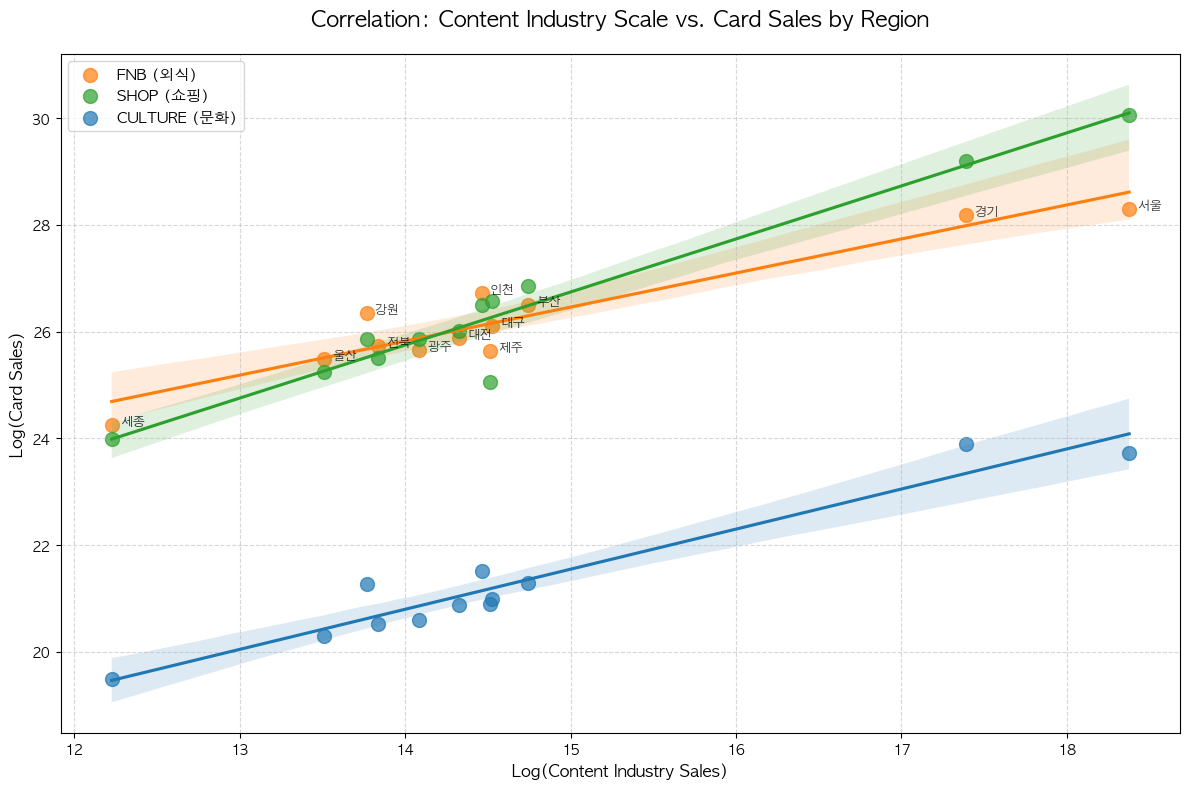

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------------------------
# 1. 데이터 로드
# --------------------------------------------------------------------------
# 사용자 지정 경로
base_path = "/Users/limtae-kyu/culture-policy-card-movie/data"
card_df = pd.read_csv(f"{base_path}/panel_sido_month.csv")

# 한글 폰트 설정 (필요시 주석 해제)
# plt.rcParams['font.family'] = 'AppleGothic'
# plt.rcParams['axes.unicode_minus'] = False

# --------------------------------------------------------------------------
# 2. 데이터 전처리 (지역별 평균 산출)
# --------------------------------------------------------------------------
# 분석에 사용된 로그 변환 변수들을 지역별로 평균냅니다.
# X축: log_content_sales (콘텐츠 산업 매출 규모)
# Y축: logVLM_FNB, logVLM_SHOP, logVLM_CULTURE (각 업종별 카드 매출 규모)
sido_avg = card_df.groupby('SIDO_SHORT')[['log_content_sales', 'logVLM_FNB', 'logVLM_SHOP', 'logVLM_CULTURE']].mean().reset_index()

# --------------------------------------------------------------------------
# 3. 시각화 (산점도 + 회귀선)
# --------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

# 각 업종별로 산점도와 회귀선 그리기
# (1) FNB (외식) - 주황색
sns.regplot(data=sido_avg, x='log_content_sales', y='logVLM_FNB',
            ax=ax, color='#FF7F0E', label='FNB (외식)', ci=95,
            scatter_kws={'s': 100, 'alpha': 0.7}) # 점 크기와 투명도 조절

# (2) SHOP (쇼핑) - 초록색
sns.regplot(data=sido_avg, x='log_content_sales', y='logVLM_SHOP',
            ax=ax, color='#2CA02C', label='SHOP (쇼핑)', ci=95,
            scatter_kws={'s': 100, 'marker': 's', 'alpha': 0.7})

# (3) CULTURE (문화) - 파란색
sns.regplot(data=sido_avg, x='log_content_sales', y='logVLM_CULTURE',
            ax=ax, color='#1F77B4', label='CULTURE (문화)', ci=95,
            scatter_kws={'s': 100, 'marker': '^', 'alpha': 0.7})

# --------------------------------------------------------------------------
# 4. 지역명 텍스트 추가 (Annotation)
# --------------------------------------------------------------------------
# 그래프의 가독성을 위해 '서울', '경기' 등 주요 지역 혹은 모든 지역 이름을 점 옆에 표시
for i, row in sido_avg.iterrows():
    # FNB 점 옆에 지역명 표시 (대표적으로 하나만 표시해도 됨)
    ax.text(row['log_content_sales'] + 0.05, row['logVLM_FNB'], row['SIDO_SHORT'],
            fontsize=9, color='black', alpha=0.8)

# --------------------------------------------------------------------------
# 5. 그래프 스타일 설정
# --------------------------------------------------------------------------
ax.set_title('Correlation: Content Industry Scale vs. Card Sales by Region', fontsize=16, pad=20)
ax.set_xlabel('Log(Content Industry Sales)', fontsize=12, fontweight='bold')
ax.set_ylabel('Log(Card Sales)', fontsize=12, fontweight='bold')

ax.legend(fontsize=11, loc='upper left', frameon=True)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

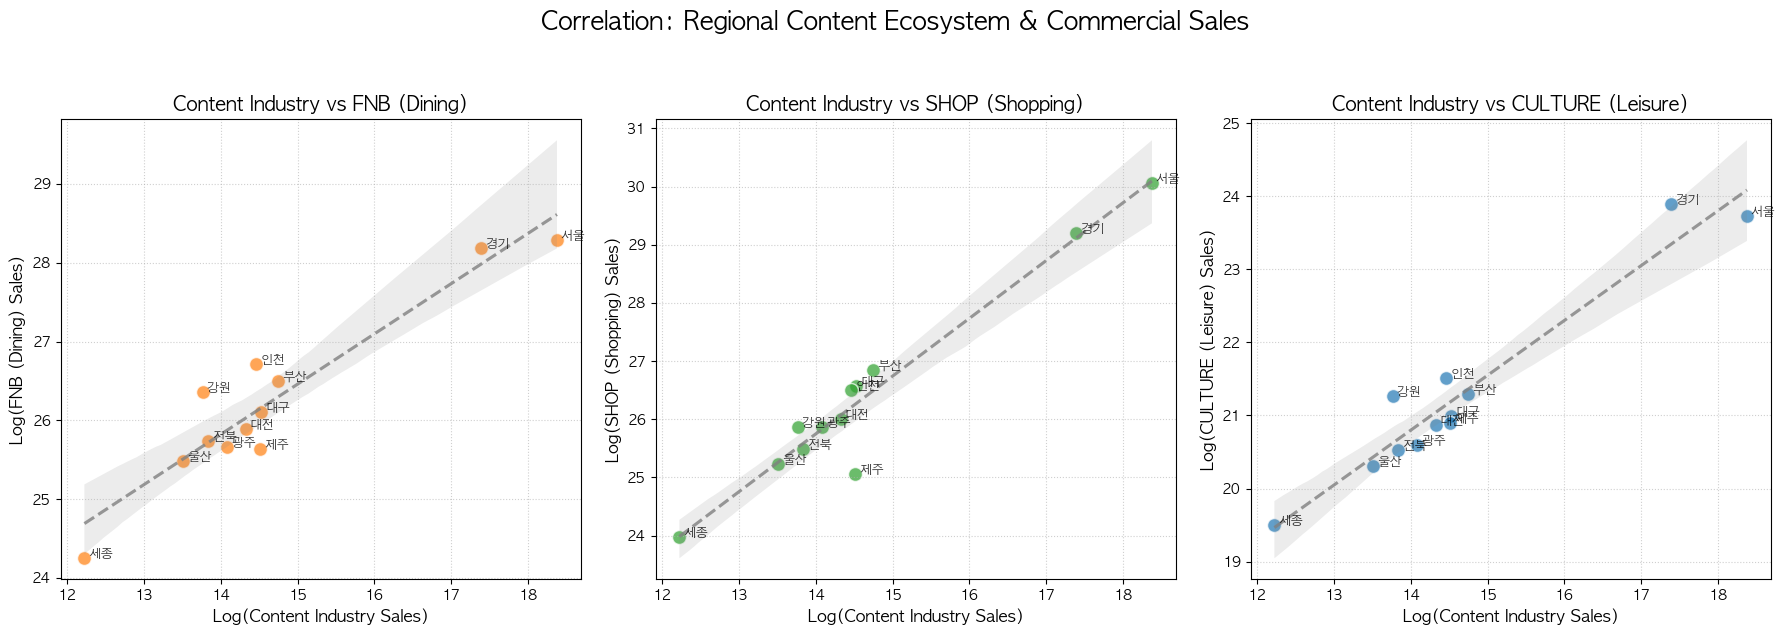

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------------------------
# 1. 데이터 로드 (경로 수정 완료)
# --------------------------------------------------------------------------
# 사용자님이 알려주신 로컬 경로
base_path = "/Users/limtae-kyu/culture-policy-card-movie/data"

# 경로를 포함하여 파일 읽기
card_df = pd.read_csv(f"{base_path}/panel_sido_month.csv")

# 한글 폰트 설정 (Mac 사용자로 추정되므로 AppleGothic 추천)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# --------------------------------------------------------------------------
# 2. 데이터 전처리
# --------------------------------------------------------------------------
# 지역별(SIDO_SHORT) 평균 계산
# log_content_sales: 2022년 기준 콘텐츠 산업 매출액의 로그값 (구조 변수)
# logVLM_FNB 등: 월별 카드 매출 로그값의 평균
sido_avg = card_df.groupby('SIDO_SHORT')[['log_content_sales', 'logVLM_FNB', 'logVLM_SHOP', 'logVLM_CULTURE']].mean().reset_index()

# --------------------------------------------------------------------------
# 3. 시각화 (Subplots)
# --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 시각화 대상 설정
targets = [
    ('logVLM_FNB', 'FNB (Dining)', '#FF7F0E'),      # 주황
    ('logVLM_SHOP', 'SHOP (Shopping)', '#2CA02C'),  # 초록
    ('logVLM_CULTURE', 'CULTURE (Leisure)', '#1F77B4') # 파랑
]

for ax, (col, label, color) in zip(axes, targets):
    # (1) 산점도 및 회귀선 그리기
    sns.regplot(x='log_content_sales', y=col, data=sido_avg, ax=ax,
                color=color,
                scatter_kws={'s': 100, 'alpha': 0.7, 'edgecolor': 'white'},
                line_kws={'color': 'gray', 'linestyle': '--', 'alpha': 0.8})

    # (2) 각 점에 지역명 텍스트 추가 (가독성을 위해 약간 오프셋)
    for i in range(sido_avg.shape[0]):
        ax.text(sido_avg.log_content_sales[i]+0.05, sido_avg[col][i],
                sido_avg.SIDO_SHORT[i], fontsize=9, fontweight='bold', alpha=0.8)

    # (3) 축 및 타이틀 꾸미기
    ax.set_title(f'Content Industry vs {label}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Log(Content Industry Sales)', fontsize=12)
    ax.set_ylabel(f'Log({label} Sales)', fontsize=12)

    # 그리드 추가
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Correlation: Regional Content Ecosystem & Commercial Sales', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

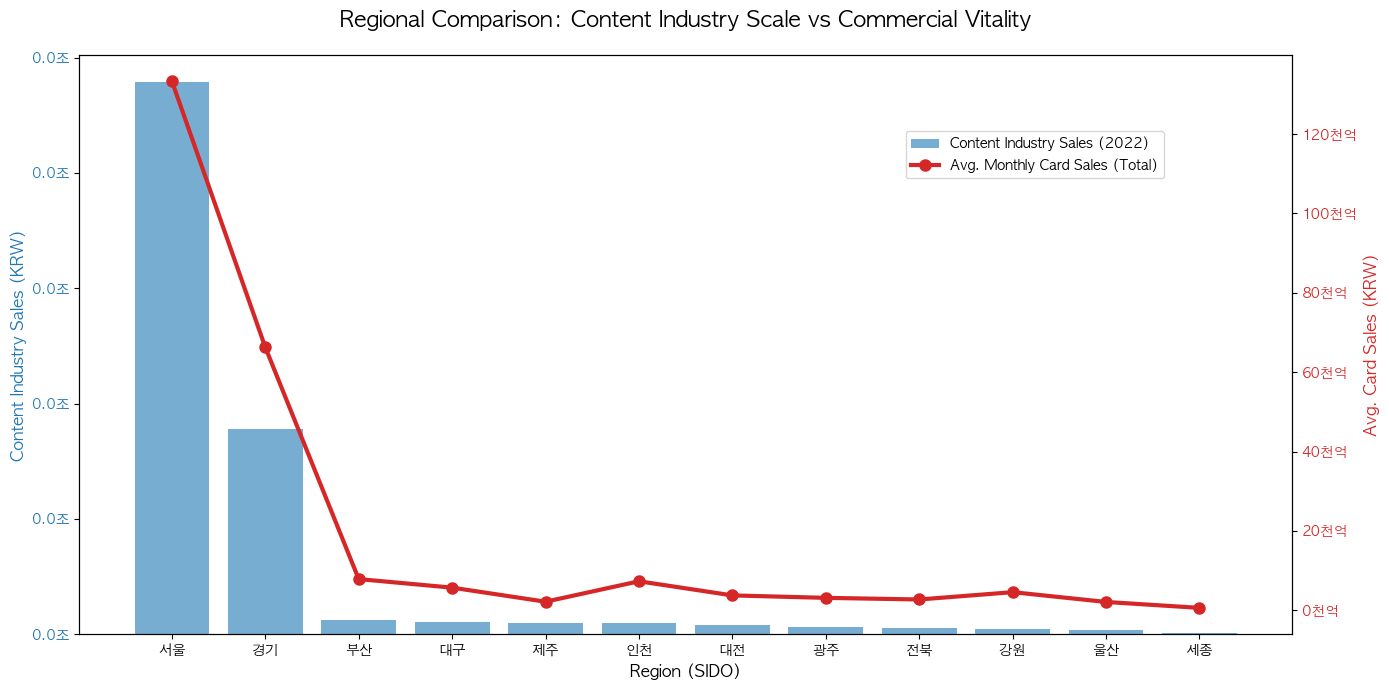

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --------------------------------------------------------------------------
# 1. 데이터 로드
# --------------------------------------------------------------------------
base_path = "/Users/limtae-kyu/culture-policy-card-movie/data"
card_df = pd.read_csv(f"{base_path}/panel_sido_month.csv")

# 한글 폰트 설정 (Mac: AppleGothic, Windows: Malgun Gothic)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# --------------------------------------------------------------------------
# 2. 데이터 전처리
# --------------------------------------------------------------------------
# (1) 지역별 그룹화
# content_sales_2022: 연간 콘텐츠 산업 매출액 (단위가 큼)
# FNB, SHOP, CULTURE: 월별 카드 매출액
sido_status = card_df.groupby('SIDO_SHORT').agg({
    'content_sales_2022': 'mean',  # 연간 매출액 (모든 월에 같은 값이므로 평균=그 값)
    'FNB': 'mean',
    'SHOP': 'mean',
    'CULTURE': 'mean'
}).reset_index()

# (2) 카드 총 매출액 계산 (3개 업종 합계)
sido_status['Card_Total'] = sido_status['FNB'] + sido_status['SHOP'] + sido_status['CULTURE']

# (3) 정렬: 콘텐츠 산업 매출액 기준 내림차순 (큰 순서대로)
sido_status = sido_status.sort_values('content_sales_2022', ascending=False)

# --------------------------------------------------------------------------
# 3. 시각화 (Combo Chart: Bar + Line)
# --------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 7))

x = sido_status['SIDO_SHORT']

# [왼쪽 Y축] 콘텐츠 산업 매출액 (막대 그래프)
ax1.bar(x, sido_status['content_sales_2022'], color='#1F77B4', alpha=0.6, label='Content Industry Sales (2022)')
ax1.set_xlabel('Region (SIDO)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Content Industry Sales (KRW)', fontsize=12, fontweight='bold', color='#1F77B4')
ax1.tick_params(axis='y', labelcolor='#1F77B4')
# 단위를 '조' 단위로 변환하여 표시 (가독성)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1000000000000:,.1f}조'))

# [오른쪽 Y축] 카드 총 매출액 (꺾은선 그래프)
ax2 = ax1.twinx()
ax2.plot(x, sido_status['Card_Total'], color='#D62728', linewidth=3, marker='o', markersize=8, label='Avg. Monthly Card Sales (Total)')
ax2.set_ylabel('Avg. Card Sales (KRW)', fontsize=12, fontweight='bold', color='#D62728')
ax2.tick_params(axis='y', labelcolor='#D62728')
# 단위를 '천억' 단위로 변환
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/100000000000:,.0f}천억'))

# 타이틀 및 범례
plt.title('Regional Comparison: Content Industry Scale vs Commercial Vitality', fontsize=16, pad=20)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88), bbox_transform=ax1.transAxes)

plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()